In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [3]:
using Revise
includet("./base.jl")

In [19]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Loading all the runs into one dataframe

In [256]:
maindir = "./main1"

files = filter(readdir(maindir; join=true)) do f
    endswith(f, ".jld2") && !endswith(f, "_fit.jld2")
end
sort!(files; by=f -> parse(Int, match(r"gi(\d+)", basename(f))[1]))

adf = mapreduce(vcat, files) do fname
    metadata, df = load(fname, "metadata", "df")
    insertcols!(df, 1,
        :file => basename(fname),
        :row_id => 1:nrow(df),
        :K => metadata.K,
        :l => metadata.l,
        :p => metadata.p,
    )
end

adf.hss_mrl = map(eachrow(adf)) do r
    M1 = Matrix{Float64}(undef, sum(get_Ns(r.params)), sum(get_Ns(r.params)))
    make_M1!(M1, r.params, r.final_states)
    maximum(real, eigvals!(M1))
end

@show nrow(adf) length(files);

nrow(adf) = 1500
length(files) = 60

In [263]:
# Filter for good data only
keep_row = map(eachrow(adf)) do r
    (r.retcodes == ReturnCode.Success) &&
    (r.maxresids < 1e-5) &&
    (r.hss_mrl < 1e-9) &&
    (r.num_surv > 0)
end
@show count(keep_row), nrow(adf)
adf = adf[keep_row, :];

(count(keep_row), nrow(adf)) = (1282, 1282)

# Do the fitting and filtering

In [652]:
ks = 10 .^ range(-5, 4, 1000)
kweight = 0.01
# kweight = 100.

# fit_mm_d itself returns nothing when the SI system is not spatially unstable
fits = Vector{Any}(undef, nrow(adf))
prog = Progress(nrow(adf))
@tasks for i in 1:nrow(adf)
    r = adf[i, :]
    fits[i] = if (r.retcodes == ReturnCode.Success) && (r.num_surv != 0)
        fit_mm_d(r.params, r.final_states, r.Dss, r.K, r.l, r.p, ks, kweight)
    end
    next!(prog)
end
finish!(prog)

for c in (:fit_d, :si_k, :mm_k, :si_h, :mm_h, :si_mrls, :mmls)
    adf[!, c] = [isnothing(f) ? missing : getproperty(f, c) for f in fits]
end

@show count(ismissing, adf.fit_d)

# Filter for spatially unstable rows only
keep_rows = map(eachrow(adf)) do r
    (!ismissing(r.fit_d)) &&
    (r.fit_d < 100.) &&
    (r.mm_h > 0.)
end
adf = adf[keep_rows,:];

Progress: 100%|█████████████████████████████████████████| Time: 0:00:08

count(ismissing, adf.fit_d) = 0

# Peak fitting stats

In [648]:
adf.deltak = log10.(adf.mm_k ./ adf.si_k)
adf.deltah = log10.(adf.mm_h ./ adf.si_h);

In [649]:
count(>(1e-3), abs.(adf.deltah))

676

(count(.!(inliers)), length(inliers)) = (0, 775)

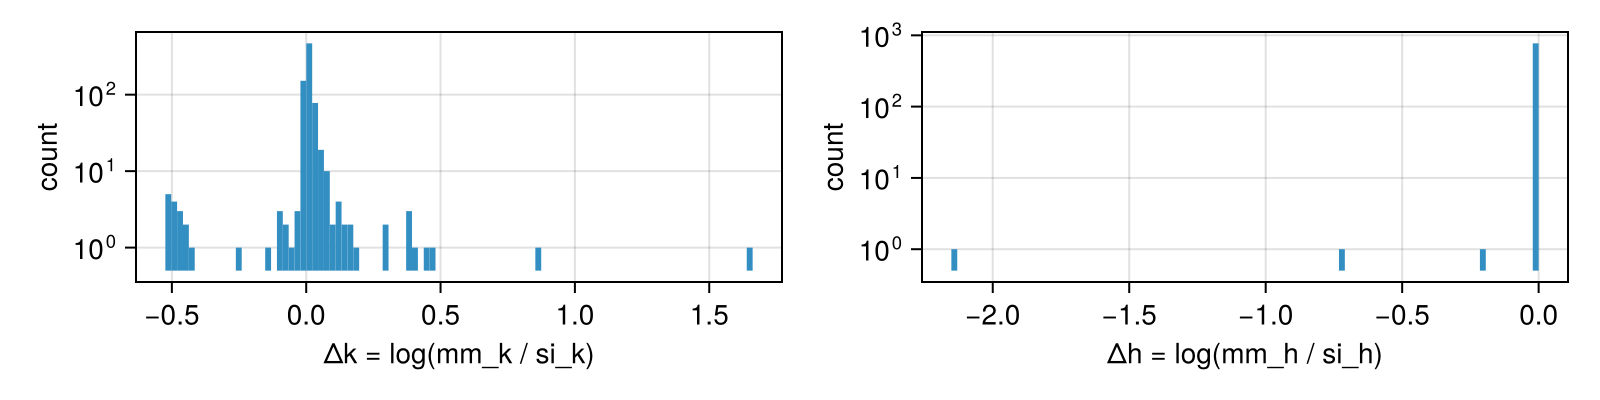

In [653]:
kcut, hcut = Inf, Inf

deltak = log10.(adf.mm_k ./ adf.si_k)
deltah = log10.(adf.mm_h ./ adf.si_h)

inliers = (abs.(deltak) .<= kcut) .& (abs.(deltah) .<= hcut)
@show count(.!inliers), length(inliers)
deltak, deltah = deltak[inliers], deltah[inliers]

fig = Figure(; size=(800, 200))
ax1 = Axis(fig[1, 1];
    xlabel="Δk = log(mm_k / si_k)",
    ylabel="count",
    yscale=log10,
)
hist!(ax1, deltak;
    bins=100
)
ax2 = Axis(fig[1, 2];
    xlabel="Δh = log(mm_h / si_h)",
    ylabel="count",
    yscale=log10,
)
# hist!(ax2, filter(>(-1e-5), deltah);
hist!(ax2, deltah;
    bins=100
)

# xlims!(ax2, -0.1, 0.001)

fig

### Old

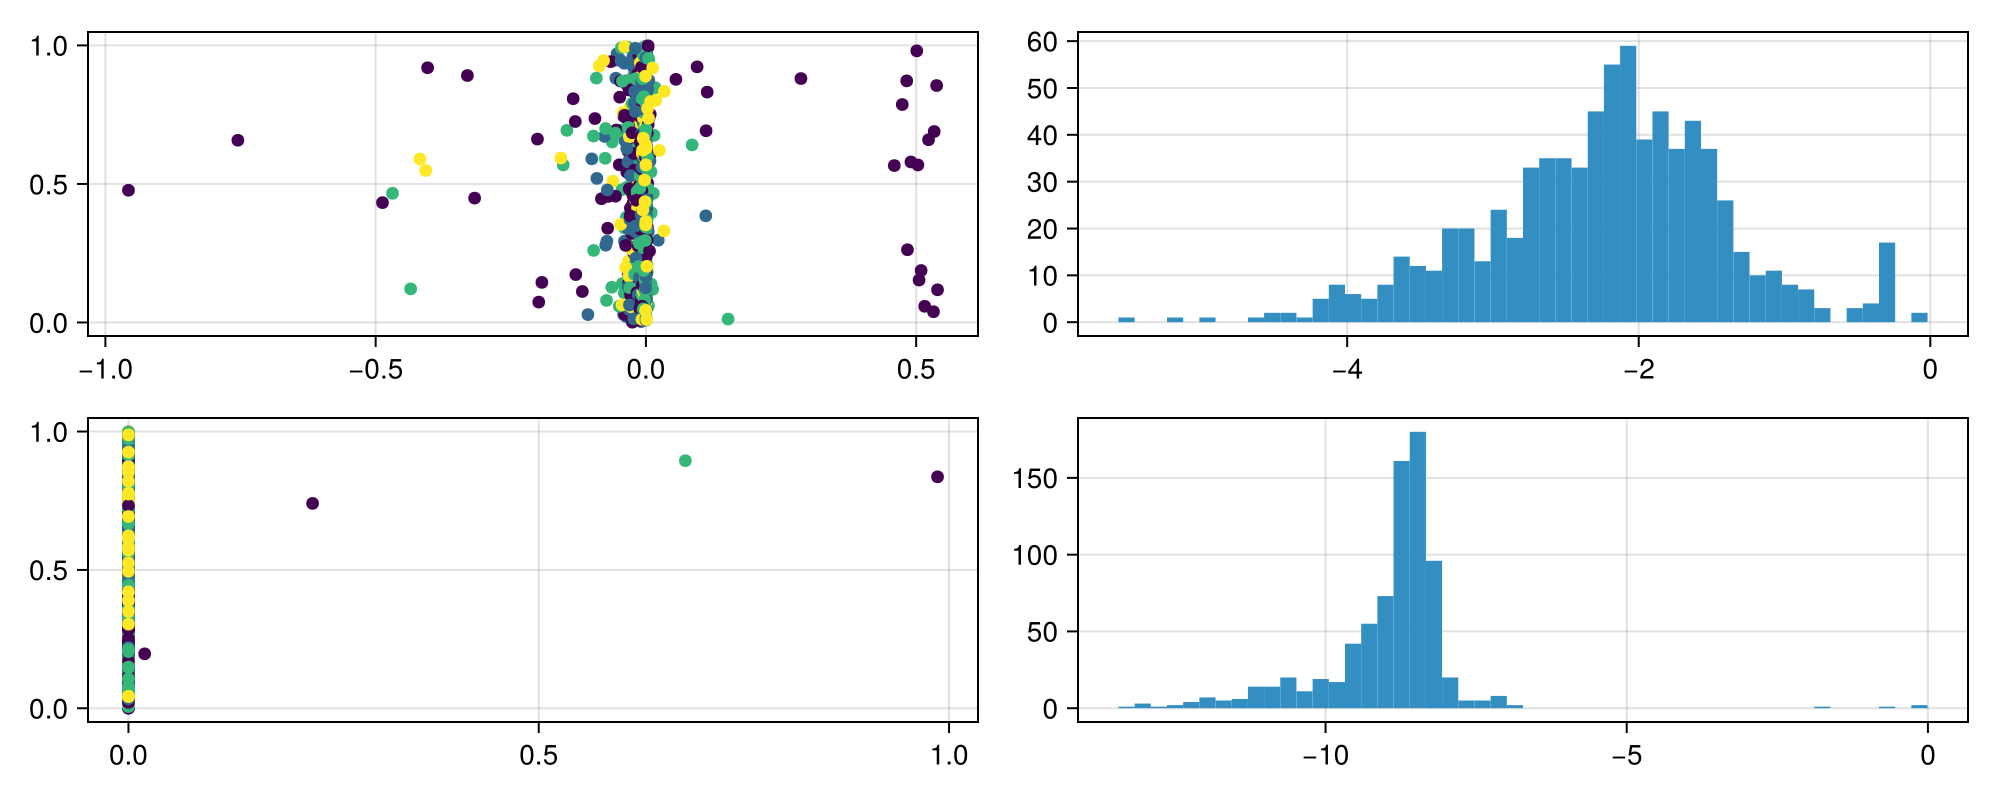

In [602]:
rel_k_error = (adf.si_k .- adf.mm_k) ./ (adf.si_k .+ adf.mm_k)
rel_h_error = (adf.si_h .- adf.mm_h) ./ (adf.si_h .+ adf.mm_h)
fig = Figure(; size=(1000, 400))
scatter!(Axis(fig[1,1]), rel_k_error, rand(length(rel_k_error));
    color=adf.K
)
scatter!(Axis(fig[2,1]), rel_h_error, rand(length(rel_h_error));
    color=adf.K
)
hist!(Axis(fig[1,2]), log10.(clamp.(abs.(rel_k_error), eps(), Inf)); bins=50)
hist!(Axis(fig[2,2]), log10.(abs.(rel_h_error)); bins=50)
# @show count(<(1e-3), abs.(rel_k_error)), length(rel_k_error)
# @show count(<(1e-3), abs.(rel_h_error)), length(rel_h_error)
fig

# Debugging weird rows

In [384]:
sdf = adf[findall(abs.(rel_h_error) .> 1e-5),:];
sort(collect(zip(sdf.si_h, sdf.mm_h)); by=x->sum(x))

117-element Vector{Tuple{Float64, Float64}}:
 (-1.0395291039352393e-8, -2.399999095108154e-7)
 (-1.6506625658556661e-9, -2.3999990951081547e-7)
 (4.5328150199894206e-9, -2.399999095108154e-7)
 (7.967537786465685e-9, -2.399999095108154e-7)
 (8.717917626713685e-9, -2.399999095108154e-7)
 (9.195560533824627e-9, -2.399999095108154e-7)
 (9.29344528956254e-9, -2.3999990951081547e-7)
 (1.334420090128526e-8, -2.399999095108154e-7)
 (3.6747364426982503e-9, -1.794763925668187e-7)
 (5.4744033915958444e-9, -1.794763925668187e-7)
 (1.6250846592106779e-10, -1.7257408427153802e-7)
 (8.908605631573284e-9, -1.7947639256681876e-7)
 (1.1089237070278537e-8, -1.7947639256681873e-7)
 ⋮
 (0.00011002192071614823, 6.96955116558668e-5)
 (0.00044811894766301545, -1.7947639256681884e-7)
 (0.0006503408206517541, -2.399999095108298e-7)
 (0.0007342634562552792, -6.579057631597936e-8)
 (0.0016656723925933324, -2.278463079681127e-18)
 (0.0016963820769934253, 0.0003247279669398813)
 (0.0020691411103137204, -2.588043864

(r.K, r.l, r.p) = (100.0, 0.99, 1.0)
r.fit_d = 0.010255415080695558
hss = [98.82456140350877, 1.0017574692442883, 0.17368112724693988]

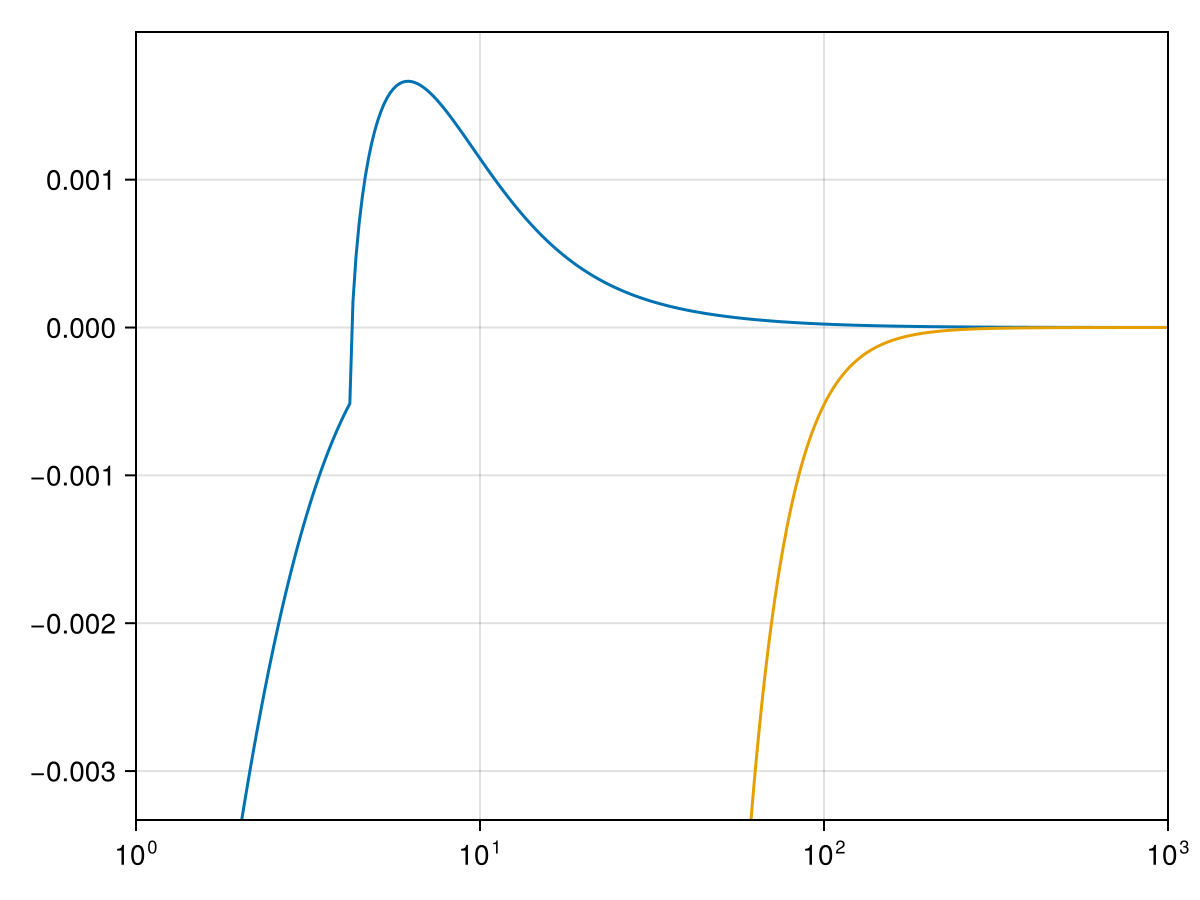

In [593]:
r = sdf[end-10,:]
@show r.K, r.l, r.p
@show r.fit_d

fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
)

d = r.fit_d
d = 5.7
mmp = MMParams(; K=r.K, l=r.l, m=1., c=1., d=d)
hss = mmv3_get_hss_unique(mmp)
@show hss
mmls = fr3_disprel_simple(mmp, 0., 1., r.p, hss[1], ks)

lines!(ax, ks, r.si_mrls)
lines!(ax, ks, mmls)

mm = abs(max(maximum(r.si_mrls), maximum(mmls)))
ylims!(ax, (-2., 1.2) .* mm)
xlims!(ax, 1e0, 1e3)

# display(GLMakie.Screen(), fig)

fig

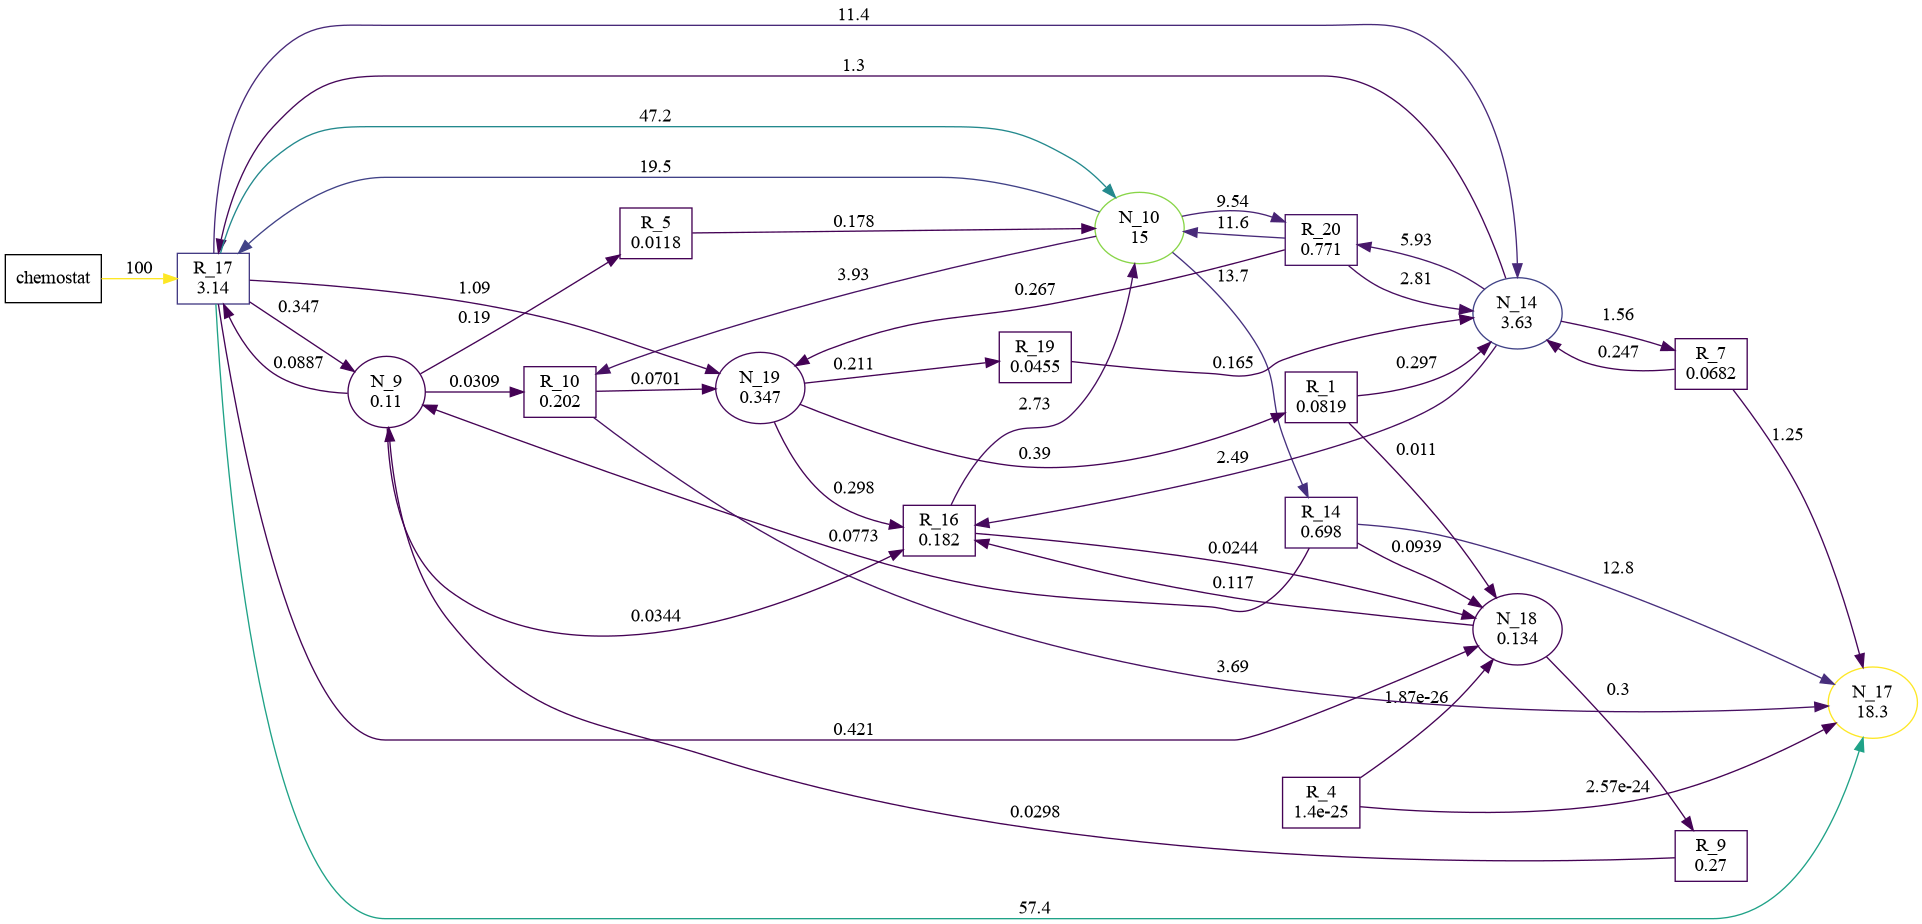

In [594]:
diagram_sfss_v3(r.params, r.final_states;
    strain_threshold=1e-1,
)